In [1]:
import sys
import os
import pandas as pd
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

print(project_root)  # para verificar

c:\Users\marco\OneDrive\Escritorio\Mis_proyectitos\electricity-price-forecast


In [2]:
from src.scraper import download_omie_price

In [3]:
df = download_omie_price("20240101")

In [4]:
df.head()

,0,1,2,3,4,5,6
0,2024,1.0,1.0,1.0,63.33,63.33,NaN
1,2024,1.0,1.0,2.0,50.09,50.09,NaN
2,2024,1.0,1.0,3.0,47.50,47.50,NaN
3,2024,1.0,1.0,4.0,43.50,43.50,NaN
4,2024,1.0,1.0,5.0,42.50,42.50,NaN


In [5]:
df.shape

(25, 7)

In [6]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')

In [7]:
df.dtypes

0     object
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
dtype: object

In [8]:
df.columns = [
    "year",
    "month",
    "day",
    "hour",
    "price_es",
    "price_pt",
    "extra"
]

In [9]:
df.head()

,year,month,day,hour,price_es,price_pt,extra
0,2024,1.0,1.0,1.0,63.33,63.33,NaN
1,2024,1.0,1.0,2.0,50.09,50.09,NaN
2,2024,1.0,1.0,3.0,47.50,47.50,NaN
3,2024,1.0,1.0,4.0,43.50,43.50,NaN
4,2024,1.0,1.0,5.0,42.50,42.50,NaN


In [10]:
df.tail()

,year,month,day,hour,price_es,price_pt,extra
20,2024,1.0,1.0,21.0,60.90,60.90,NaN
21,2024,1.0,1.0,22.0,60.00,60.00,NaN
22,2024,1.0,1.0,23.0,47.50,47.50,NaN
23,2024,1.0,1.0,24.0,42.09,42.09,NaN
24,*,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df.drop(columns='extra')
df.columns

Index(['year', 'month', 'day', 'hour', 'price_es', 'price_pt'], dtype='object')

In [12]:
df = df.drop(index=24)
df.tail()

,year,month,day,hour,price_es,price_pt
19,2024,1.0,1.0,20.0,54.97,54.97
20,2024,1.0,1.0,21.0,60.90,60.90
21,2024,1.0,1.0,22.0,60.00,60.00
22,2024,1.0,1.0,23.0,47.50,47.50
23,2024,1.0,1.0,24.0,42.09,42.09


In [13]:
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]].rename(columns={"hour": "hour"}),
    format="%Y %m %d %H"
)
#Format datetime from the columns year, month, day, hour

In [14]:
df.head()

,year,month,day,hour,price_es,price_pt,datetime
0,2024,1.0,1.0,1.0,63.33,63.33,2024-01-01 01:00:00
1,2024,1.0,1.0,2.0,50.09,50.09,2024-01-01 02:00:00
2,2024,1.0,1.0,3.0,47.50,47.50,2024-01-01 03:00:00
3,2024,1.0,1.0,4.0,43.50,43.50,2024-01-01 04:00:00
4,2024,1.0,1.0,5.0,42.50,42.50,2024-01-01 05:00:00


In [15]:
df = df.sort_values("datetime")
#make sure it is ordered

<Axes: xlabel='datetime'>

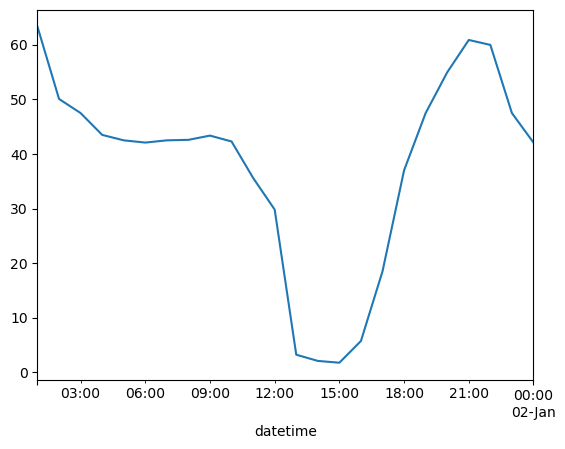

In [16]:
df.set_index("datetime")["price_es"].plot()

In [18]:
from src.scraper import download_omie_range

In [19]:
dfs = download_omie_range("20240101", "20240115")
    

OK: 20240101
OK: 20240102
OK: 20240103
OK: 20240104
OK: 20240105
OK: 20240106
OK: 20240107
OK: 20240108
OK: 20240109
OK: 20240110
OK: 20240111
OK: 20240112
OK: 20240113
OK: 20240114
OK: 20240115


In [20]:
df_all = pd.concat(dfs, ignore_index=True)

In [21]:
df_all.sample()

,0,1,2,3,4,5,6
79,2024,1.0,4.0,5.0,66.86,66.86,NaN


In [22]:
df_all.shape

(375, 7)

In [23]:
dfs[1]

,0,1,2,3,4,5,6
0,2024,1.0,2.0,1.0,37.80,37.80,NaN
1,2024,1.0,2.0,2.0,25.61,25.00,NaN
2,2024,1.0,2.0,3.0,20.61,3.99,NaN
3,2024,1.0,2.0,4.0,14.54,14.00,NaN
4,2024,1.0,2.0,5.0,13.21,10.00,NaN
5,2024,1.0,2.0,6.0,14.54,14.54,NaN
6,2024,1.0,2.0,7.0,36.29,36.29,NaN
7,2024,1.0,2.0,8.0,44.70,44.70,NaN
8,2024,1.0,2.0,9.0,53.78,53.78,NaN
9,2024,1.0,2.0,10.0,54.23,54.23,NaN


In [24]:
df_all.columns

Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')

In [25]:
df_all.columns = [
    "year",
    "month",
    "day",
    "hour",
    "price_es",
    "price_pt",
    "extra"
]

In [26]:
df_all.columns

Index(['year', 'month', 'day', 'hour', 'price_es', 'price_pt', 'extra'], dtype='object')

In [27]:
df_all = df_all.drop(columns='extra')

In [28]:
df_all.columns

Index(['year', 'month', 'day', 'hour', 'price_es', 'price_pt'], dtype='object')

In [29]:
df_all = df_all[pd.to_numeric(df_all["year"], errors="coerce").notna()]
# Turns years that are not '*' into Nan because it tries to turn them in numeric.
# Then, we keep the years that are notna

In [30]:
df_all = df_all.dropna()
# Now, dropna to every row with at least one Nan. It could have work by its own before.

In [34]:
df_all.sample(4)

,year,month,day,hour,price_es,price_pt
89,2024,1.0,4.0,15.0,92.11,92.11
151,2024,1.0,7.0,2.0,79.82,79.82
63,2024,1.0,3.0,14.0,63.35,55.42
31,2024,1.0,2.0,7.0,36.29,36.29


In [35]:
df_all.dtypes

year         object
month       float64
day         float64
hour        float64
price_es    float64
price_pt    float64
dtype: object

In [37]:
df_all.year = df_all.year.astype('float64')
df_all.dtypes

year        float64
month       float64
day         float64
hour        float64
price_es    float64
price_pt    float64
dtype: object

In [38]:
df_all["datetime"] = pd.to_datetime(df_all[["year", "month", "day", "hour"]])
# Construct again the datetime column

In [39]:
df_all["dayofweek"] = df_all["datetime"].dt.dayofweek
df_all["is_weekend"] = (df_all["dayofweek"] >= 5)
#Day of the week is 0-6. 5 and 6 are Saturday Sunday

In [40]:
df_all.sample(2)

,year,month,day,hour,price_es,price_pt,datetime,dayofweek,is_weekend
272,2024.0,1.0,11.0,23.0,100.00,100.00,2024-01-11 23:00:00,3,False
236,2024.0,1.0,10.0,12.0,102.97,102.97,2024-01-10 12:00:00,2,False


In [41]:
df_all["lag_1"] = df_all["price_es"].shift(1)
# Adds lag_1 to shift 1 hour. Then connect time step 

In [42]:
df_all["lag_24"] = df_all["price_es"].shift(24)
# Adds lag_24 to shift 24 hours. Then connect day step

In [43]:
df_all.head(10)

,year,month,day,hour,price_es,price_pt,datetime,dayofweek,is_weekend,lag_1,lag_24
0,2024.0,1.0,1.0,1.0,63.33,63.33,2024-01-01 01:00:00,0,False,NaN,NaN
1,2024.0,1.0,1.0,2.0,50.09,50.09,2024-01-01 02:00:00,0,False,63.33,NaN
2,2024.0,1.0,1.0,3.0,47.50,47.50,2024-01-01 03:00:00,0,False,50.09,NaN
3,2024.0,1.0,1.0,4.0,43.50,43.50,2024-01-01 04:00:00,0,False,47.50,NaN
4,2024.0,1.0,1.0,5.0,42.50,42.50,2024-01-01 05:00:00,0,False,43.50,NaN
5,2024.0,1.0,1.0,6.0,42.09,42.09,2024-01-01 06:00:00,0,False,42.50,NaN
6,2024.0,1.0,1.0,7.0,42.50,42.50,2024-01-01 07:00:00,0,False,42.09,NaN
7,2024.0,1.0,1.0,8.0,42.59,42.59,2024-01-01 08:00:00,0,False,42.50,NaN
8,2024.0,1.0,1.0,9.0,43.37,43.37,2024-01-01 09:00:00,0,False,42.59,NaN
9,2024.0,1.0,1.0,10.0,42.29,42.29,2024-01-01 10:00:00,0,False,43.37,NaN


Next, we will see how to proceed to detect if there are discontinuities in time for the dataset. If there were, the lags aforehead implemented would break by finding some missing values. When dealing with big data do this first

In [44]:
df_all = df_all.set_index("datetime")
df_all = df_all.sort_index()
# Temporal index

In [ ]:
full_range = pd.date_range(start=df_all.index.min(), end=df_all.index.max(), freq="H")
# All ranges of time that should exist from start minimum and final maximum. It adds in frequency 'H'
# which means every hour

C:\Users\marco\AppData\Local\Temp\ipykernel_26216\3508378159.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df_all.index.min(), end=df_all.index.max(), freq="H")


In [ ]:
missing = full_range.difference(df_all.index)

print(len(missing))
missing[:10]
# The ones missing from the expected range are stored in missing

0


DatetimeIndex([], dtype='datetime64[ns]', freq='h')

In [49]:
# Now that we Know that is continue we can clean the Nans
df_all = df_all.dropna()

In [ ]:
df_all.corr(numeric_only=True)["price_es"].sort_values(ascending=False)
# Pearson correlation of the numerical variables (numeric only) with 'price_es'

price_es      1.000000
price_pt      0.998820
lag_1         0.954339
lag_24        0.630145
day           0.412648
hour          0.324545
dayofweek    -0.207120
is_weekend   -0.246882
year               NaN
month              NaN
Name: price_es, dtype: float64

<Axes: xlabel='datetime'>

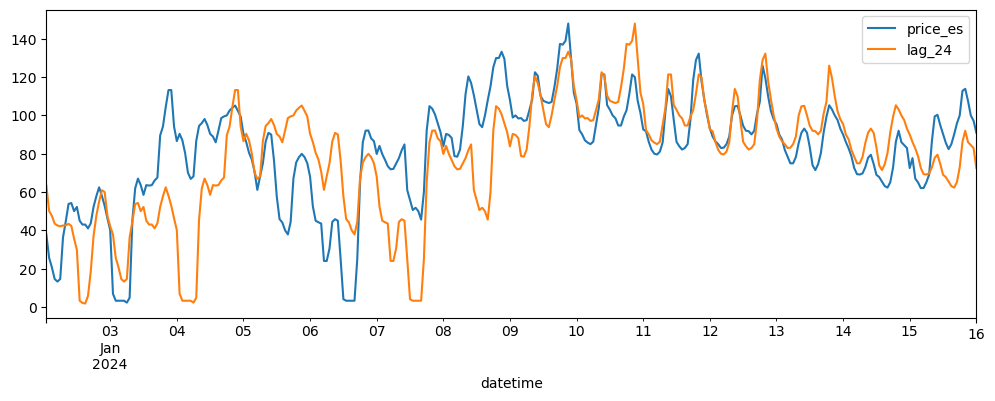

In [51]:
df_all[["price_es", "lag_24"]].plot(figsize=(12,4))
# Nothing but the plot of the price and its lag_24 to certify

IMPORTANT INSIGHT!!!
Correlation of lag_1 more than lag_24 and this is certified in the plot. The lag_24 do not overlap too much until 9 of January. This is due to vacation period. After it they match much more. 

# Now let´s go to the first model

In [52]:
y = df_all["price_es"]
# The variable to predict

In [53]:
X = df_all[[
    "lag_1",
    "lag_24",
    "hour",
    "dayofweek",
    "is_weekend"
]]

# The features used to predict

In [ ]:
split = int(len(df_all) * 0.8)  #This represents 80% of the dataset

X_train = X.iloc[:split]  #Past (0-80%)
X_test = X.iloc[split:]   #Future(80-100%)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Temporal split. Train with past and predict future

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# First model Linear Regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
preds = model.predict(X_test)
# Predictions made with the model trained with X_train and y_train

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)
# The mean_absolute error in the price from 'real' future y_test and the predicted preds
print(mae)

4.452704800611127


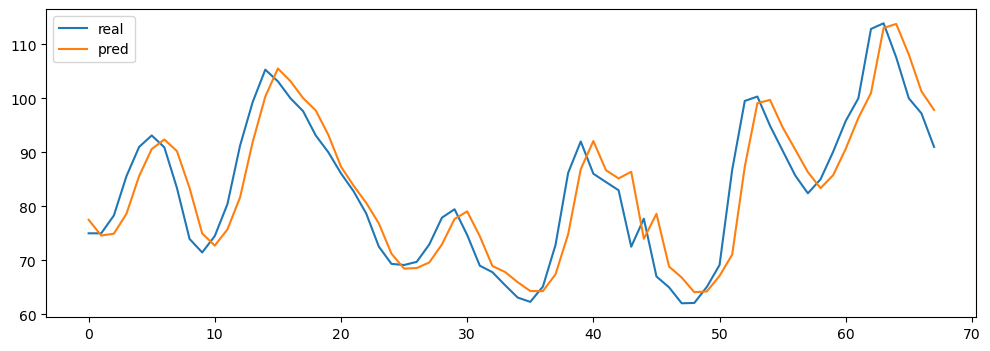

In [ ]:
import matplotlib.pyplot as plt
# Plot of the real value and the prediction
plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="real")
plt.plot(preds, label="pred")
plt.legend()
plt.show()

The baseline model achieves a MAE of approximately 4.45 €/MWh, which is a reasonable performance given its simplicity and the limited feature set based only on lag variables and basic calendar information. The predicted curve closely follows the overall shape of the real price series, indicating that the model successfully captures the main temporal structure and seasonality of the electricity market. However, there is a noticeable slight time shift and smoothing effect in the predictions, which suggests that the linear model is able to capture general trends but struggles with abrupt changes and short-term volatility. This behavior is expected, as linear regression primarily learns average relationships and cannot fully model nonlinear dynamics or sudden market shocks. Overall, the results confirm that the model is a strong baseline and that electricity prices exhibit significant autocorrelation and daily seasonality, particularly consistent with patterns observed in the OMIE electricity market.

# Adding new features to the model (rollings and ciclical time)

In [59]:
df_all["rolling_24h"] = df_all["price_es"].shift(1).rolling(24).mean()
df_all["rolling_168h"] = df_all["price_es"].shift(1).rolling(168).mean()
# It adds the rollings as the mean of previous 24 hours or 168 hours (1 day and 1 week).
# This smooths the peaks

In [64]:
df_all.head(5)

,year,month,day,hour,price_es,price_pt,dayofweek,is_weekend,lag_1,lag_24,rolling_24h,rolling_168h
datetime,,,,,,,,,,,,
2024-01-02 01:00:00,2024.0,1.0,2.0,1.0,37.80,37.80,1,False,42.09,63.33,NaN,NaN
2024-01-02 02:00:00,2024.0,1.0,2.0,2.0,25.61,25.00,1,False,37.80,50.09,NaN,NaN
2024-01-02 03:00:00,2024.0,1.0,2.0,3.0,20.61,3.99,1,False,25.61,47.50,NaN,NaN
2024-01-02 04:00:00,2024.0,1.0,2.0,4.0,14.54,14.00,1,False,20.61,43.50,NaN,NaN
2024-01-02 05:00:00,2024.0,1.0,2.0,5.0,13.21,10.00,1,False,14.54,42.50,NaN,NaN


In [65]:
df_all = df_all.drop(columns='rolling_168h')
# The rolling generates Nans at the beggining, this dataset is short. Let´s not continue with 168h
df_all = df_all.dropna()
df_all.head(5)

,year,month,day,hour,price_es,price_pt,dayofweek,is_weekend,lag_1,lag_24,rolling_24h
datetime,,,,,,,,,,,
2024-01-03 01:00:00,2024.0,1.0,3.0,1.0,6.8,6.8,2,False,40.1,37.80,41.782083
2024-01-03 02:00:00,2024.0,1.0,3.0,2.0,3.2,3.2,2,False,6.8,25.61,40.490417
2024-01-03 03:00:00,2024.0,1.0,3.0,3.0,3.2,3.2,2,False,3.2,20.61,39.556667
2024-01-03 04:00:00,2024.0,1.0,3.0,4.0,3.2,3.2,2,False,3.2,14.54,38.831250
2024-01-03 05:00:00,2024.0,1.0,3.0,5.0,3.2,3.2,2,False,3.2,13.21,38.358750


In [66]:
df_all.shape

(312, 11)

In [67]:
import numpy as np
# Ciclical hours, period of 24
df_all["hour_sin"] = np.sin(2 * np.pi * df_all["hour"] / 24)
df_all["hour_cos"] = np.cos(2 * np.pi * df_all["hour"] / 24)

In [68]:
df_all["week_sin"] = np.sin(2 * np.pi * df_all["dayofweek"] / 7)
df_all["week_cos"] = np.cos(2 * np.pi * df_all["dayofweek"] / 7)
# Also ciclical in weeks

Now let´s make another model with all this new features!!

In [69]:
df_all.columns

Index(['year', 'month', 'day', 'hour', 'price_es', 'price_pt', 'dayofweek',
       'is_weekend', 'lag_1', 'lag_24', 'rolling_24h', 'hour_sin', 'hour_cos',
       'week_sin', 'week_cos'],
      dtype='object')

In [70]:
y = df_all.price_es

In [73]:
X = df_all[[
    "lag_1",
    "lag_24",
    "rolling_24h",
    "hour_sin",
    "hour_cos",
    "week_sin",
    "week_cos",
    "is_weekend"]]

In [75]:
split = int(len(df_all) * 0.8)  #This represents 80% of the dataset

X_train = X.iloc[:split]  #Past (0-80%)
X_test = X.iloc[split:]   #Future(80-100%)

y_train = y.iloc[:split]
y_test = y.iloc[split:]


In [76]:
model_2 = LinearRegression()
model_2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
preds_2 = model_2.predict(X_test)

In [78]:
mae = mean_absolute_error(y_test, preds_2)
# The mean_absolute error in the price from 'real' future y_test and the predicted preds
print(mae)

4.383215849802681


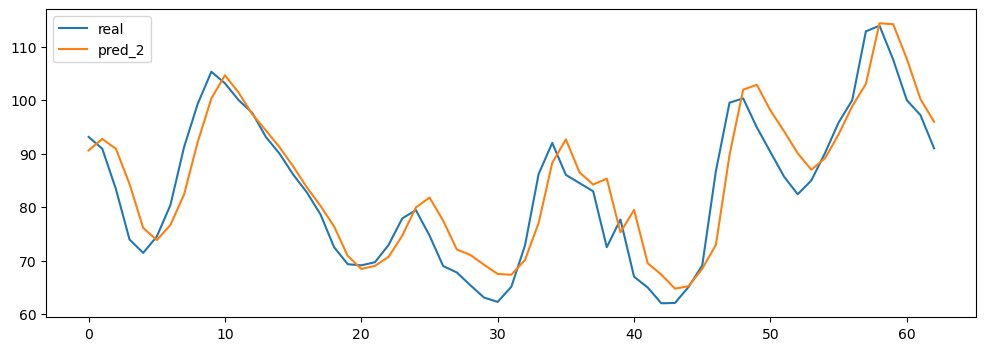

In [79]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="real")
plt.plot(preds_2, label="pred_2")
plt.legend()
plt.show()

SMALL DEVIATION LET'S SEE IF LINEAR REGRESSION AT LEAST IS BETTER THAN A "DUMB" BASELINE.
(FOR THIS LET'S WORK ONLY WITH PRICE OF PREVIOUS DAY)

In [83]:
X_base = df_all[["lag_24"]]
Y_base = df_all["price_es"]

In [84]:
split = int(len(df_all) * 0.8)  #This represents 80% of the dataset

X_train = X_base.iloc[:split]  #Past (0-80%)
X_test = X_base.iloc[split:]   #Future(80-100%)

Y_train = Y_base.iloc[:split]
Y_test = Y_base.iloc[split:]

In [85]:
base_model = LinearRegression()
base_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
preds_base = base_model.predict(X_test)

In [87]:
mae_base = mean_absolute_error(preds_base, Y_test)
print(mae_base)

12.451822270598527


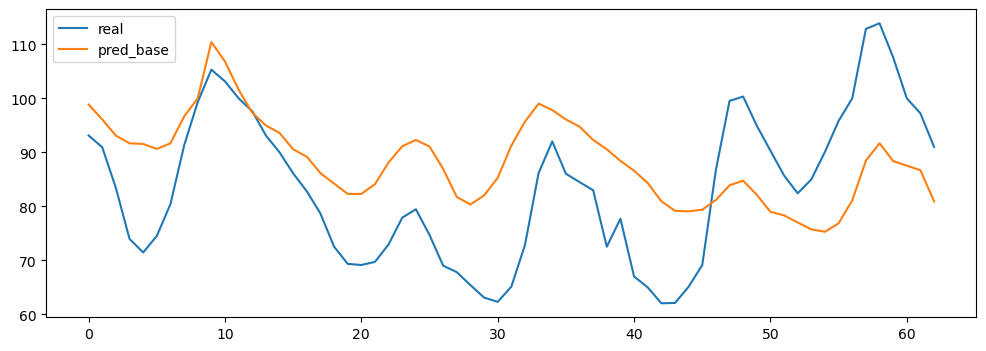

In [89]:
plt.figure(figsize=(12,4))
plt.plot(Y_test.values, label="real")
plt.plot(preds_base, label="pred_base")
plt.legend()
plt.show()

Perfect!! It captures more or less periodicity but of course does not fit values

# More complicated models (Random Forest and XGBoost)

In [90]:
from sklearn.ensemble import RandomForestRegressor

In [98]:
Y = df_all["price_es"]
X = df_all[[
    "lag_1",
    "lag_24",
    "rolling_24h",
    "hour_sin",
    "hour_cos",
    "week_sin",
    "week_cos",
    "is_weekend"]]

In [102]:
# Let´s continue with same splitting
split = int(len(df_all)*0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
Y_train = Y.iloc[:split]
Y_test = Y.iloc[split:]

First Forest Model

In [103]:
RF_1 = RandomForestRegressor(random_state=42)

In [104]:
RF_1.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
pred_rf1 = RF_1.predict(X_test)
mae = mean_absolute_error(pred_rf1, Y_test)
print(mae)

4.119415873015883


In [108]:
# Individual plot of RF1
#plt.figure(figsize=(12,4))
#plt.plot(Y_test.values, label="real")
#plt.plot(pred_rf1, label="pred_rf1")
#plt.legend()
#plt.show()

Second Random Forest (Controlling more variables)

In [109]:
RF_2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

In [110]:
RF_2.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [111]:
pred_rf2 = RF_2.predict(X_test)
mae = mean_absolute_error(pred_rf2, Y_test)
print(mae)

4.339631225578179


In [112]:
# Individual plot of RF2
# #plt.figure(figsize=(12,4))
#plt.plot(Y_test.values, label="real")
#plt.plot(pred_rf2, label="pred_rf2")
#plt.legend()
#plt.show()

Third Random Forest (More flexible)

In [113]:
RF_3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42
)

In [114]:
RF_3.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [115]:
pred_rf3 = RF_3.predict(X_test)
mae = mean_absolute_error(pred_rf3, Y_test)
print(mae)

3.936524109662377


In [ ]:
# Individual plot of RF3
#plt.figure(figsize=(12,4))
#plt.plot(Y_test.values, label="real")
#plt.plot(pred_rf3, label="pred_rf3")
#plt.legend()
#plt.show()

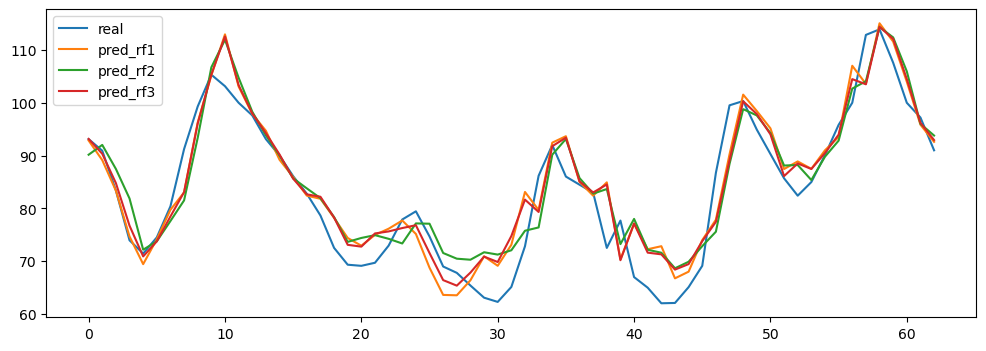

In [117]:
# Combined plot of RF1, RF2, RF3
plt.figure(figsize=(12,4))
plt.plot(Y_test.values, label="real")
plt.plot(pred_rf1, label="pred_rf1")
plt.plot(pred_rf2, label="pred_rf2")
plt.plot(pred_rf3, label="pred_rf3")
plt.legend()
plt.show()

The Random Forest models demonstrate a clear improvement over the linear regression baseline (and much more respect to crude 24h variable), reducing the MAE from approximately 4.45 to as low as 3.94 in the best configuration. Unlike the linear model, the Random Forest is able to better capture nonlinear relationships and short-term variations in the electricity price series, resulting in predictions that are more closely aligned in time with the actual values and without the noticeable lag observed previously. While the overall shape of the predicted curves remains similar across different Random Forest configurations, the more flexible model achieves better accuracy by adjusting more precisely to local fluctuations. In contrast, the more regularized version exhibits signs of underfitting, particularly in specific intervals where it fails to capture sharper variations. These results suggest that model flexibility plays a key role in capturing the dynamics of electricity prices, and that ensemble methods such as Random Forest provide a more suitable framework than linear approaches for this type of time series forecasting problem.